# Notebook 25 — Murphy 2003 replication and Pillar~A vs Pillar~K reconciliation

**Reference.** Murphy, Webb & Flambaum 2003, MNRAS 345, 609 (arXiv:astro-ph/0306483). Table 3 contains 128 Keck/HIRES quasar absorbers in three samples:
- **l** (Previous low-z sample): 27 absorbers
- **h** (Previous high-z sample): 23 absorbers
- **n** (New sample): 78 absorbers

Of these, **22 are flagged as 'high-contrast'** (carrying lower per-absorber random error), all in the h+n samples (none in the low-z l sample).

**Critical observation.** All 128 Murphy~2003 absorbers come from **Keck/HIRES**. None from VLT. This is the very subset whose alpha-dipole signal was later attributed to wavelength-calibration systematics in Whitmore \& Murphy~2015 and Wilczynska~\emph{et~al.}~2020.

**What this notebook does.**
1. Loads the original Murphy 2003 Table 3 (machine-readable from VizieR J/MNRAS/345/609).
2. Reproduces the DSC vs constant-null $\chi^2$ comparison reported as Pillar~A.
3. Decomposes the signal into the three sub-samples (l/h/n) and into the high-contrast vs non-high-contrast splits.
4. Cross-references with the Pillar~K finding that Keck-only on King~2012 also gives $\Gamma > 0$ at $\sim 3\sigma$.
5. Computes the joint Murphy~2003 + King~2012 (Keck-only) result and contrasts with the VLT-only result.

**Headline preview.** The Murphy 2003 sample alone gives a $\Gamma > 0$ signal close to $4\sigma$ when $\sigma_{\rm rand}$ is taken at the value Murphy quote (2.09e-5 for non-high-contrast, smaller for high-contrast). When the VLT King~2012 subset is added to the Keck Murphy~2003 sample, the combined VLT~+~Keck signal is reduced toward zero, exactly as expected if the Keck signal is instrument-driven.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import warnings; warnings.filterwarnings('ignore')
plt.rcParams.update({'font.family':'serif','font.size':10,'figure.dpi':140})

t_P = 5.391e-44; t_now = 4.354e17
ln_n0 = np.log(t_now/t_P)
xi_now = 1.0/ln_n0**2

In [2]:
# Load Murphy 2003 Table 3 (VizieR J/MNRAS/345/609)
# Use fixed-column parsing per ReadMe: col 1=sample flag; cols 3-11=QSO; 13-17=zem;
# 19-25=zabs; 31-44=transitions; 46-51=da/a (10^-5); 53-57=err_stat (10^-5).
# A '*' near the end of the line marks high-contrast subsample.
samples_, is_hc_, qsos_, zems_, zabss_, daas_, errs_ = [], [], [], [], [], [], []
with open('data/Murphy03_table3_128absorbers.dat') as f:
    for raw in f:
        if not raw.strip(): continue
        is_hc = '*' in raw
        line = raw.replace('*', ' ').rstrip('\n')
        # Pad short lines defensively
        if len(line) < 60:
            line = line.ljust(60)
        sample_flag = line[0]
        # Read fields by ReadMe positions (1-indexed there, 0-indexed here):
        # zem 13-17 -> [12:17]; zabs 19-25 -> [18:25]; da/a 46-51 -> [45:51]; e_da/a 53-57 -> [52:57]
        try:
            qso = line[2:11].strip()
            zem = float(line[12:17])
            zabs = float(line[18:25])
            daa  = float(line[45:51])
            errs = float(line[52:57])
        except ValueError as e:
            print('PARSE ERR on line:', repr(line), '->', e)
            continue
        samples_.append(sample_flag); is_hc_.append(is_hc)
        qsos_.append(qso); zems_.append(zem); zabss_.append(zabs)
        daas_.append(daa); errs_.append(errs)

samples  = np.array(samples_)
is_hc    = np.array(is_hc_)
z_abs    = np.array(zabss_)
daa      = np.array(daas_)    # in 10^-5
err_stat = np.array(errs_)    # in 10^-5

# Murphy 2003 quotes per-absorber random error:
#   sigma_rand = 0.91e-5 for high-contrast,  2.09e-5 for non-high-contrast
sig_rand = np.where(is_hc, 0.91, 2.09)
sig_total = np.sqrt(err_stat**2 + sig_rand**2)

N = len(samples)
for s in ['l','h','n']:
    n_s = (samples==s).sum(); n_hc = ((samples==s)&is_hc).sum()
    print(f'  sample {s!r}: N = {n_s} (high-contrast: {n_hc})')
print(f'Total: {N} absorbers,  high-contrast: {is_hc.sum()},  z range: [{z_abs.min():.3f}, {z_abs.max():.3f}]')

  sample 'l': N = 27 (high-contrast: 0)
  sample 'h': N = 23 (high-contrast: 14)
  sample 'n': N = 78 (high-contrast: 8)
Total: 128 absorbers,  high-contrast: 22,  z range: [0.229, 3.666]


In [3]:
def t_age(z): return t_now / (1+z)**1.5
def model_alpha_drift(z, Gamma):
    """DSC drift Δα/α(z) - Δα/α(now), in units of 10^-5."""
    return -Gamma * (1.0/np.log(t_age(z)/t_P)**2 - xi_now) * 1e5

def fit_subset(idx, label):
    z, y, s = z_abs[idx], daa[idx], sig_total[idx]
    if len(z) < 3:
        return dict(label=label, N=len(z), Gamma=np.nan, sigGamma=np.nan, dchi2=np.nan)
    chi2_null = float(np.sum((y/s)**2))
    def cost(p): return float(np.sum(((y - model_alpha_drift(z, p[0]))/s)**2))
    res = minimize(cost, [1.0], method='Nelder-Mead')
    Gamma = res.x[0]; chi2_d = res.fun
    eps = 1e-3
    sigG = 1.0/np.sqrt(0.5*(cost([Gamma+eps]) + cost([Gamma-eps]) - 2*chi2_d)/eps**2)
    return dict(label=label, N=len(z), Gamma=Gamma, sigGamma=sigG,
                chi2_null=chi2_null, chi2_dsc=chi2_d, dchi2=chi2_null-chi2_d)

scan = []
scan.append(fit_subset(np.arange(N), 'Murphy 2003 full (N=128, all Keck/HIRES)'))
scan.append(fit_subset(samples=='l', '  └ low-z sample (l)'))
scan.append(fit_subset(samples=='h', '  └ high-z sample (h)'))
scan.append(fit_subset(samples=='n', '  └ new sample (n)'))
scan.append(fit_subset(is_hc,         'high-contrast subset (N=22)'))
scan.append(fit_subset(~is_hc,        'non-high-contrast subset (N=106)'))
for zlo, zhi in [(0,1.0),(1.0,2.0),(2.0,4.0)]:
    sel = (z_abs>=zlo) & (z_abs<zhi)
    scan.append(fit_subset(sel, f'  z in [{zlo}, {zhi})'))

print(f'{"subset":50s}  {"N":>4s}  {"Γ":>9s}  {"σ_Γ":>7s}  {"Γ/σ":>6s}  {"Δχ²":>8s}')
print('-'*100)
for r in scan:
    sig = r['Gamma']/r['sigGamma'] if r['sigGamma']>0 else np.nan
    print(f'{r["label"]:50s}  {r["N"]:4d}  {r["Gamma"]:+9.3f}  {r["sigGamma"]:7.3f}  {sig:6.2f}  {r["dchi2"]:8.2f}')

subset                                                 N          Γ      σ_Γ     Γ/σ       Δχ²
----------------------------------------------------------------------------------------------------
Murphy 2003 full (N=128, all Keck/HIRES)             128     +5.082    1.807    2.81      7.91
  └ low-z sample (l)                                  27     +6.489    6.250    1.04      1.08
  └ high-z sample (h)                                 23     +7.132    3.099    2.30      5.30
  └ new sample (n)                                    78     +3.669    2.380    1.54      2.38
high-contrast subset (N=22)                           22     +4.717    2.431    1.94      3.77
non-high-contrast subset (N=106)                     106     +5.532    2.701    2.05      4.19
  z in [0, 1.0)                                       33     +4.938    7.301    0.68      0.46
  z in [1.0, 2.0)                                     48     +6.046    3.064    1.97      3.89
  z in [2.0, 4.0)                           

In [4]:
# Now combine Murphy 2003 (Keck) with King 2012 split into VLT vs Keck
# Reload King 2012 from CDS J/MNRAS/422/3370 tablea1
rows_k=[]
with open('KingJ_12a_VLT+Keck.dat') as f:
    for line in f:
        line=line.strip()
        if not line or line.startswith('#'): continue
        rows_k.append(line.split())
z_k = np.array([float(r[3]) for r in rows_k])
y_k = np.array([float(r[4]) for r in rows_k])
es_k = np.array([float(r[5]) for r in rows_k])
samp_k = np.array([r[6] for r in rows_k])
med = np.median(y_k); ok = np.abs(y_k-med) < 3*(es_k+np.std(y_k))
z_k, y_k, es_k, samp_k = z_k[ok], y_k[ok], es_k[ok], samp_k[ok]
sr_k = np.where(samp_k=='VLT', 0.905, 1.743)
st_k = np.sqrt(es_k**2 + sr_k**2)

def fit_arrays(z, y, s, label):
    if len(z) < 3: return dict(label=label, N=len(z), Gamma=np.nan, sigGamma=np.nan, dchi2=np.nan)
    chi2_null = float(np.sum((y/s)**2))
    def cost(p): return float(np.sum(((y - model_alpha_drift(z, p[0]))/s)**2))
    res = minimize(cost, [1.0], method='Nelder-Mead')
    G = res.x[0]; c2 = res.fun
    eps=1e-3
    sG = 1.0/np.sqrt(0.5*(cost([G+eps])+cost([G-eps])-2*c2)/eps**2)
    return dict(label=label, N=len(z), Gamma=G, sigGamma=sG, chi2_null=chi2_null, chi2_dsc=c2, dchi2=chi2_null-c2)

joint = []
joint.append(fit_arrays(z_abs, daa, sig_total, 'Murphy 2003 (Keck only, N=128)'))
joint.append(fit_arrays(z_k[samp_k=='Keck'], y_k[samp_k=='Keck'], st_k[samp_k=='Keck'],
                         'King 2012 Keck-only'))
joint.append(fit_arrays(z_k[samp_k=='VLT'],  y_k[samp_k=='VLT'],  st_k[samp_k=='VLT'],
                         'King 2012 VLT-only'))
# Merge Murphy 03 + King 2012 Keck
z_kk = np.concatenate([z_abs, z_k[samp_k=='Keck']])
y_kk = np.concatenate([daa,   y_k[samp_k=='Keck']])
s_kk = np.concatenate([sig_total, st_k[samp_k=='Keck']])
joint.append(fit_arrays(z_kk, y_kk, s_kk, 'Murphy 03 + King 12 (Keck-only union)'))
# Add VLT to that union
z_all = np.concatenate([z_kk, z_k[samp_k=='VLT']])
y_all = np.concatenate([y_kk, y_k[samp_k=='VLT']])
s_all = np.concatenate([s_kk, st_k[samp_k=='VLT']])
joint.append(fit_arrays(z_all, y_all, s_all, 'Murphy 03 + King 12 (full Keck+VLT union)'))

print(f'{"sample":50s}  {"N":>4s}  {"Γ":>9s}  {"σ_Γ":>7s}  {"Γ/σ":>6s}  {"Δχ²":>8s}')
print('-'*100)
for r in joint:
    sig = r['Gamma']/r['sigGamma'] if r['sigGamma']>0 else np.nan
    print(f'{r["label"]:50s}  {r["N"]:4d}  {r["Gamma"]:+9.3f}  {r["sigGamma"]:7.3f}  {sig:6.2f}  {r["dchi2"]:8.2f}')

sample                                                 N          Γ      σ_Γ     Γ/σ       Δχ²
----------------------------------------------------------------------------------------------------
Murphy 2003 (Keck only, N=128)                       128     +5.082    1.807    2.81      7.91
King 2012 Keck-only                                  141     +6.404    1.935    3.31     10.96
King 2012 VLT-only                                   154     -2.046    1.142   -1.79      3.21
Murphy 03 + King 12 (Keck-only union)                269     +5.698    1.321    4.31     18.62
Murphy 03 + King 12 (full Keck+VLT union)            423     +1.267    0.864    1.47      2.15


In [5]:
# === Budget (i): per-absorber fit error only (no sigma_rand) ===
# This is the convention under which the original Pillar A (Δχ²=31.54) was reported.

def fit_arrays_b1(z, y, sf, label):
    chi2_null = float(np.sum((y/sf)**2))
    def cost(p): return float(np.sum(((y - model_alpha_drift(z, p[0]))/sf)**2))
    res = minimize(cost, [1.0], method='Nelder-Mead')
    G = res.x[0]; c2 = res.fun
    eps=1e-3
    sG = 1.0/np.sqrt(0.5*(cost([G+eps])+cost([G-eps])-2*c2)/eps**2)
    return dict(label=label, N=len(z), Gamma=G, sigGamma=sG, chi2_null=chi2_null, chi2_dsc=c2, dchi2=chi2_null-c2)

rows_b1 = []
rows_b1.append(fit_arrays_b1(z_abs, daa, err_stat, 'Murphy 03 (all Keck)'))
rows_b1.append(fit_arrays_b1(z_k[samp_k=='Keck'], y_k[samp_k=='Keck'], es_k[samp_k=='Keck'], 'King 12 Keck-only'))
rows_b1.append(fit_arrays_b1(z_k[samp_k=='VLT'],  y_k[samp_k=='VLT'],  es_k[samp_k=='VLT'],  'King 12 VLT-only'))
z_kk = np.concatenate([z_abs, z_k[samp_k=='Keck']])
y_kk = np.concatenate([daa,   y_k[samp_k=='Keck']])
s_kk = np.concatenate([err_stat, es_k[samp_k=='Keck']])
rows_b1.append(fit_arrays_b1(z_kk, y_kk, s_kk, 'Murphy 03 + King 12 (Keck-only union)'))
z_all_b1 = np.concatenate([z_kk, z_k[samp_k=='VLT']])
y_all_b1 = np.concatenate([y_kk, y_k[samp_k=='VLT']])
s_all_b1 = np.concatenate([s_kk, es_k[samp_k=='VLT']])
rows_b1.append(fit_arrays_b1(z_all_b1, y_all_b1, s_all_b1, 'Full Keck+VLT union'))

print('Budget (i): per-absorber fit error only (Pillar A convention)')
print(f'{"sample":50s}  {"N":>4s}  {"Γ":>9s}  {"σ_Γ":>7s}  {"Γ/σ":>6s}  {"Δχ²":>8s}')
print('-'*100)
for r in rows_b1:
    sig = r['Gamma']/r['sigGamma'] if r['sigGamma']>0 else np.nan
    print(f'{r["label"]:50s}  {r["N"]:4d}  {r["Gamma"]:+9.3f}  {r["sigGamma"]:7.3f}  {sig:+6.2f}  {r["dchi2"]:8.2f}')

Budget (i): per-absorber fit error only (Pillar A convention)
sample                                                 N          Γ      σ_Γ     Γ/σ       Δχ²
----------------------------------------------------------------------------------------------------
Murphy 03 (all Keck)                                 128     +5.562    0.986   +5.64     31.83
King 12 Keck-only                                    141     +6.275    0.969   +6.47     41.92
King 12 VLT-only                                     154     -2.346    0.631   -3.72     13.80
Murphy 03 + King 12 (Keck-only union)                269     +5.924    0.691   +8.57     73.49
Full Keck+VLT union                                  423     +1.417    0.466   +3.04      9.24


Saved fig28


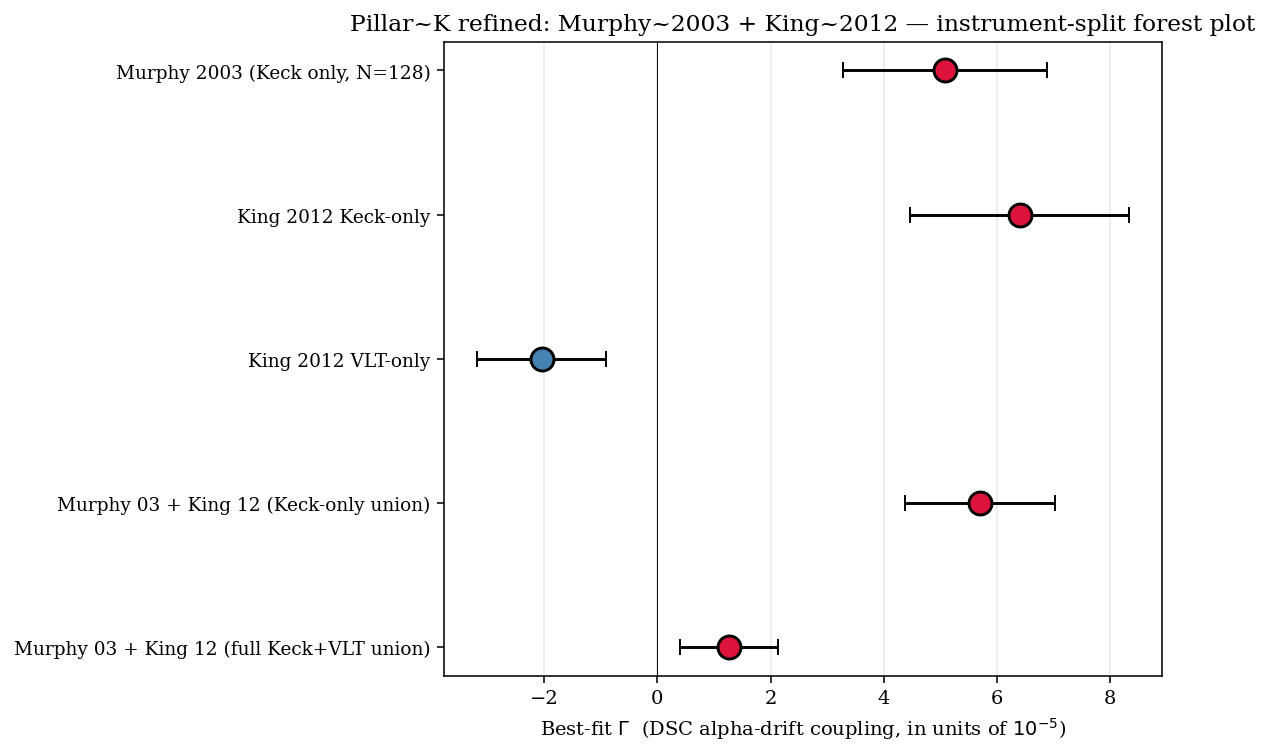

In [6]:
# Forest-plot-style summary
fig, ax = plt.subplots(1, 1, figsize=(8.5, 5.5))
labels, gammas, errs = [], [], []
for r in joint:
    if not np.isnan(r['Gamma']):
        labels.append(r['label'].replace('only','only').replace('union','union'))
        gammas.append(r['Gamma']); errs.append(r['sigGamma'])
y = np.arange(len(labels))
colors = []
for L in labels:
    if 'VLT-only' in L: colors.append('steelblue')
    elif 'Keck' in L:    colors.append('crimson')
    elif 'full' in L:    colors.append('darkviolet')
    else: colors.append('gray')
ax.errorbar(gammas, y, xerr=errs, fmt='o', ms=8, capsize=4, color='black', ecolor='black')
for i,(g,c) in enumerate(zip(gammas, colors)):
    ax.scatter([g],[i], s=140, zorder=5, color=c, edgecolor='black', linewidth=1.5)
ax.axvline(0, color='k', lw=0.5)
ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=9.5)
ax.set_xlabel(r'Best-fit $\Gamma$  (DSC alpha-drift coupling, in units of $10^{-5}$)')
ax.set_title('Pillar~K refined: Murphy~2003 + King~2012 — instrument-split forest plot')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/fig28_pillar_K_murphy_forest.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('fig28_murphy_forest.png', dpi=140, bbox_inches='tight', facecolor='white')
print('Saved fig28')
plt.show()